# **Course 1 - Exploratory Data Analysis for Machine Learning**
**Waze Project**

## **Objectives**

**The purpose** of this project is to perform exploratory data analysis (EDA) on the Waze user dataset to better understand user engagement patterns and factors associated with monthly churn. 

*The analysis focuses on:*

- Identifying behavioral differences between retained and churned users
- Detecting missing values, outliers, and data quality issues
- Engineering meaningful features for future predictive modeling
- Evaluating relationships between variables using statistical testing
- Generating actionable insights that may help improve user retention

## **Data Exploration Plan**
**Part 1. Data Understanding** \
Review dataset structure, variable types, summary statistics, and target variable distribution.

**Part 2. Data Cleaning** \
Identify missing values, duplicates, and outliers to improve overall data quality and reliability.

**Part 3. Exploratory Data Analysis (EDA)**
Investigate relationships between user behavior variables and churn status using summary statistics and visualizations.

**Part 4. Feature Engineering** \
Transform categorical variables, evaluate correlations, and prepare features for future machine learning applications.

**Part 5. Statistical Testing** \
Test hypotheses regarding user behavior and churn using t-tests, ANOVA, and chi-square

**Part 6. Conclusion** \
Summarize key behavioral patterns associated with churn and identify variables that may be important predictors.

## **Workflow**

### **Part 1. Imports and data loading**

For EDA of the data, import the data and packages that will be most helpful, such as pandas, numpy, and matplotlib.




In [1]:
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency


This project uses a dataset called `waze_dataset.csv`. It contains synthetic data created for this project in partnership with Waze. 
The data is already in a structured format. Each row represents a user.

In [2]:
# Load the dataset into a dataframe
df = pd.read_csv('waze_dataset.csv')

**Data Summary**

The `waze_dataset.csv` dataset contains user-level activity data from the Waze app over a one-month period. The dataset contains 14,999 observations and 13 variables, including numerical and categorical features describing user activity, driving behavior, and app engagement.

The primary target variable is `label`, which indicates whether a user was retained or churned during the month. Since churn prediction is the main business objective, understanding the behavioral differences between retained and churned users is a major focus of this analysis.

The dataset includes:

- User engagement variables (`sessions`, `activity_days`)
- Driving behavior variables (`drives`, `driving_days`, `driven_km_drives`)
-Navigation behavior variables (`total_navigations_fav1` `total_navigations_fav2`)
- Device information (`device`)
- Lifecycle features (`n_days_after_onboarding`)

These variables may provide important signals associated with user retention and churn.

### **Part 2. Data cleaning**

#### **2.1 Data overview and summary statistics**

Use the following methods and attributes on the dataframe:

* `head()`
* `size`
* `describe()`
* `info()`

In [3]:
df.head(10)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone


In [4]:
df.size

194987

Generate summary statistics using the `describe()` method.

In [5]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


And summary information using the `info()` method.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


##### **Findings:**

1. The dataset contains 13 unique variables with types including objects, ﬂoats, and integers;.

2. The variables `label` and `device` are of type `object`; `total_sessions`, `driven_km_drives`, and `duration_minutes_drives` are of type `float64`; the rest of the variables are of type `int64`. There are 14,999 rows and 13 columns.

3. The dataset has 700 missing values in the `label` column.

#### **2.2 Missing values**

##### **Null value summary**

Compare the summary statistics of the 700 rows that are missing labels with summary statistics of the rows that are not missing any values.

In [7]:
# Isolate rows with null values
null_df = df[df['label'].isnull()]
# Display summary stats of rows with null values
null_df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,7405.584286,80.837143,67.798571,198.483348,1709.295714,118.717143,30.371429,3935.967029,1795.123358,15.382857,12.125714
std,4306.900234,79.987440,65.271926,140.561715,1005.306562,156.308140,46.306984,2443.107121,1419.242246,8.772714,7.626373
min,77.000000,0.000000,0.000000,5.582648,16.000000,0.000000,0.000000,290.119811,66.588493,0.000000,0.000000
25%,3744.500000,23.000000,20.000000,94.056340,869.000000,4.000000,0.000000,2119.344818,779.009271,8.000000,6.000000
50%,7443.000000,56.000000,47.500000,177.255925,1650.500000,62.500000,10.000000,3421.156721,1414.966279,15.000000,12.000000
75%,11007.000000,112.250000,94.000000,266.058022,2508.750000,169.250000,43.000000,5166.097373,2443.955404,23.000000,18.000000
max,14993.000000,556.000000,445.000000,1076.879741,3498.000000,1096.000000,352.000000,15135.391280,9746.253023,31.000000,30.000000


In [8]:
# Isolate rows without null values
not_null_df = df[~df['label'].isnull()]
# Display summary stats of rows without null values
not_null_df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,7503.573117,80.623820,67.255822,189.547409,1751.822505,121.747395,29.638296,4044.401535,1864.199794,15.544653,12.182530
std,4331.207621,80.736502,65.947295,136.189764,1008.663834,147.713428,45.350890,2504.977970,1448.005047,9.016088,7.833835
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000
50%,7504.000000,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000
75%,11257.500000,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


##### **Findings:**

> Comparing summary statistics of the observations with missing retention labels with those that aren't missing any values reveals nothing remarkable. The means and standard deviations are fairly consistent between the two groups.

##### **Null value patttern**

Next, check the two populations with respect to the `device` variable. How many iPhone users had null values and how many Android users had null values?

If the missing data are missing completely at random (MCAR), meaning that the reason for missingness is independent of the data values themselves, we can proceed with a complete-case analysis by removing the rows with missing values. Otherwise, we need to investigate the root cause of the missingness and make sure it won't interfere with the statistical inference and modeling.

In [9]:
# Get count of null values by device
null_df['device'].value_counts()

device
iPhone     447
Android    253
Name: count, dtype: int64

##### **Findngs:**
> Of the 700 rows with null values, 447 were iPhone users and 253 were Android users.

Of the rows with null values, calculate the percentage with each device&mdash;Android and iPhone with the [`value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) function.

In [10]:
# Calculate % of iPhone nulls and Android nulls
null_df['device'].value_counts(normalize=True)

device
iPhone     0.638571
Android    0.361429
Name: proportion, dtype: float64

We compare it to the device ratio in the full dataset.

In [11]:
# Calculate % of iPhone users and Android users in full dataset
df['device'].value_counts(normalize=True)

device
iPhone     0.644843
Android    0.355157
Name: proportion, dtype: float64

**Findings:**
> The percentage of missing values by each device is consistent with their representation in the data overall.
> There is nothing to suggest a non-random cause of the missing data.

##### **Drop missing values**

Because there is no evidence of a non-random cause of the 700 missing values in the `label` column, and because these observations comprise less than 5% of the data, use the `dropna()` method to drop the rows that are missing this data.

In [12]:
# Drop rows with missing values
df = df.dropna(subset=['label'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14299 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14299 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14299 non-null  int64  
 3   drives                   14299 non-null  int64  
 4   total_sessions           14299 non-null  float64
 5   n_days_after_onboarding  14299 non-null  int64  
 6   total_navigations_fav1   14299 non-null  int64  
 7   total_navigations_fav2   14299 non-null  int64  
 8   driven_km_drives         14299 non-null  float64
 9   duration_minutes_drives  14299 non-null  float64
 10  activity_days            14299 non-null  int64  
 11  driving_days             14299 non-null  int64  
 12  device                   14299 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


#### **2.3 Duplicates**
Check if duplicates exist

In [13]:
df.duplicated().sum()

0

##### **Findngs:**
> No duplicates in the dataset

#### **2.4 Outliers**

##### **Find the outliers**
**Uni-variate Analysis**
*    Box plots determines outliers and where the bulk of the data points reside and all other continuous numeric variables
*    Histograms show the distribution of variables

In [14]:
def plot_sessions_distribution(df, column):
    median = round(df[column].median(), 1)
    
    # Calculate the full range of the data to force the view
    data_min = df[column].min()
    data_max = df[column].max()
    # Add a little padding (5%) so points aren't touching the edge
    padding = (data_max - data_min) * 0.05
    
    fig, axes = plt.subplots(
        2, 1,
        figsize=(8, 6),
        gridspec_kw={'height_ratios': [2, 3]},
        sharex=True
    )
    
    # --- Boxplot ---
    sns.boxplot(
        x=df[column],
        ax=axes[0],
        fliersize=4,
        whis=1.5
    )
    axes[0].set_title(f'{column} box plot')
    
    # --- Histogram ---
    sns.histplot(
        x=df[column],
        ax=axes[1],
        kde=True
    )
    
    # FORCE the x-axis to show everything from min to max
    axes[1].set_xlim(data_min - padding, data_max + padding)
    
    # Median line
    axes[1].axvline(median, color='red', linestyle='--')
    
    # Adjust text position so it's always visible
    axes[1].text(
        0.5, 0.9,
        f'median={median}',
        color='red',
        transform=axes[1].transAxes,
        ha='right'
    )
    
    axes[1].set_title(f'{column} histogram')
    
    plt.tight_layout()
    plt.show()

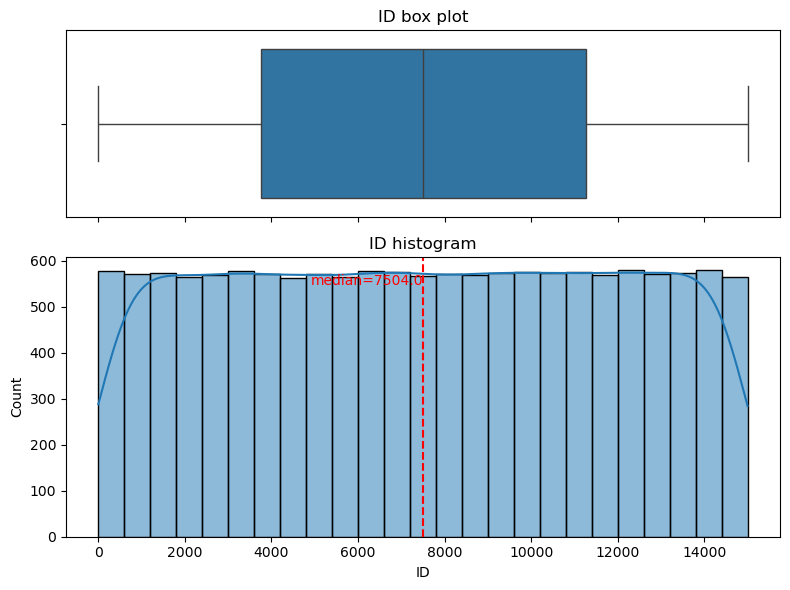

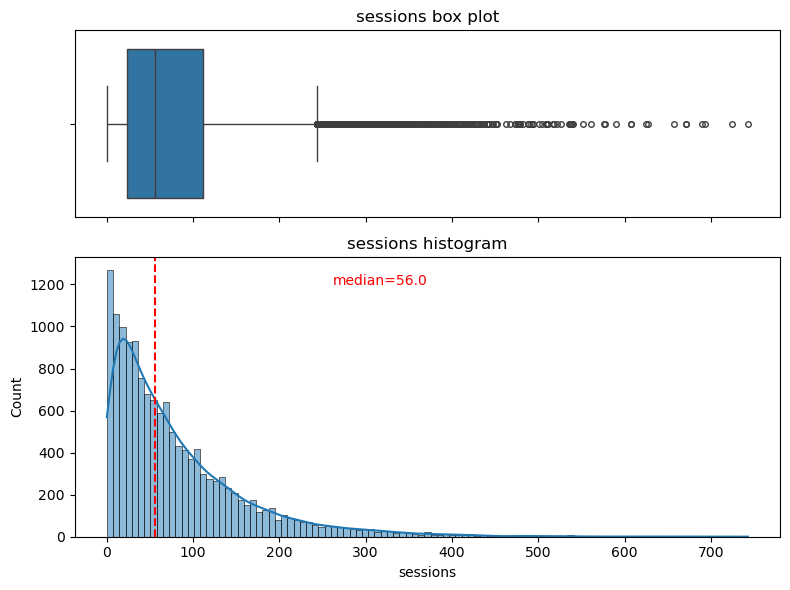

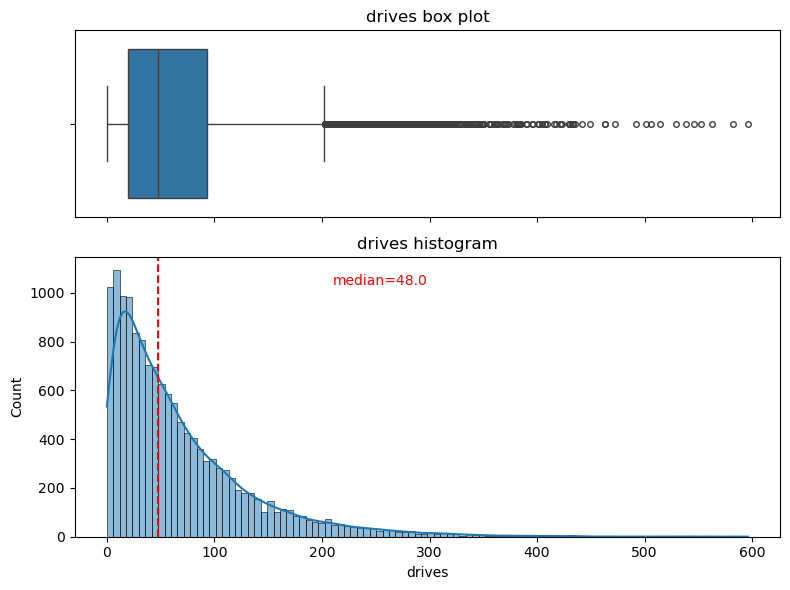

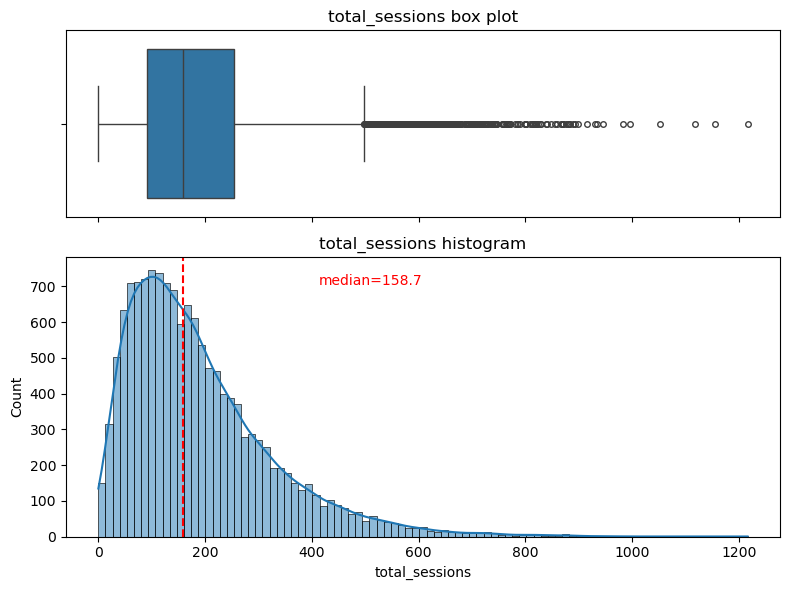

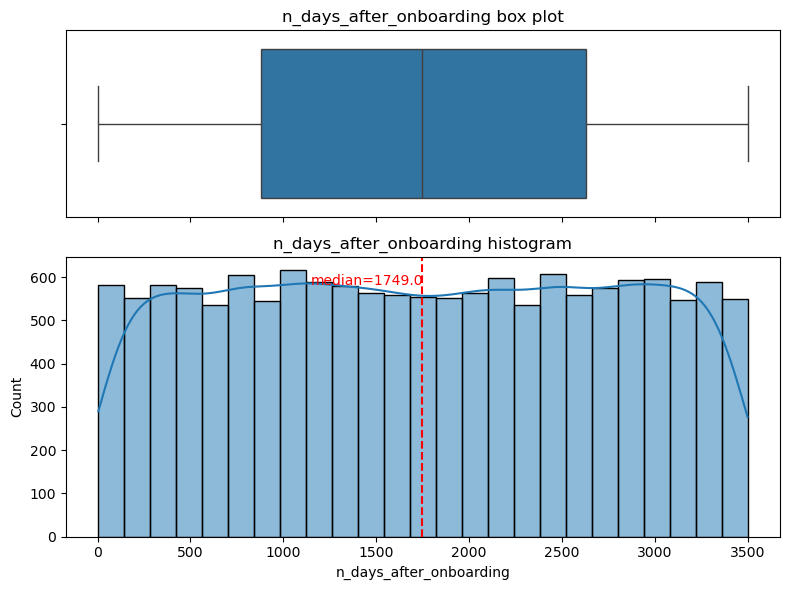

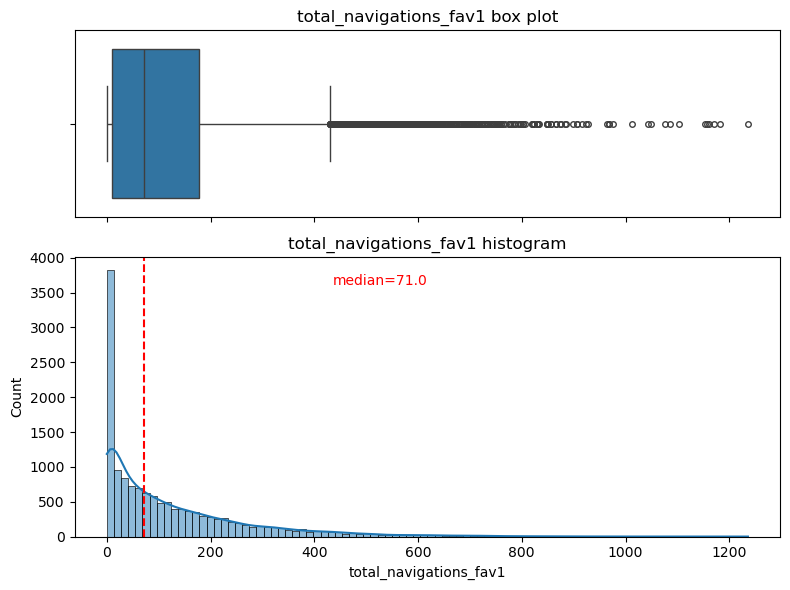

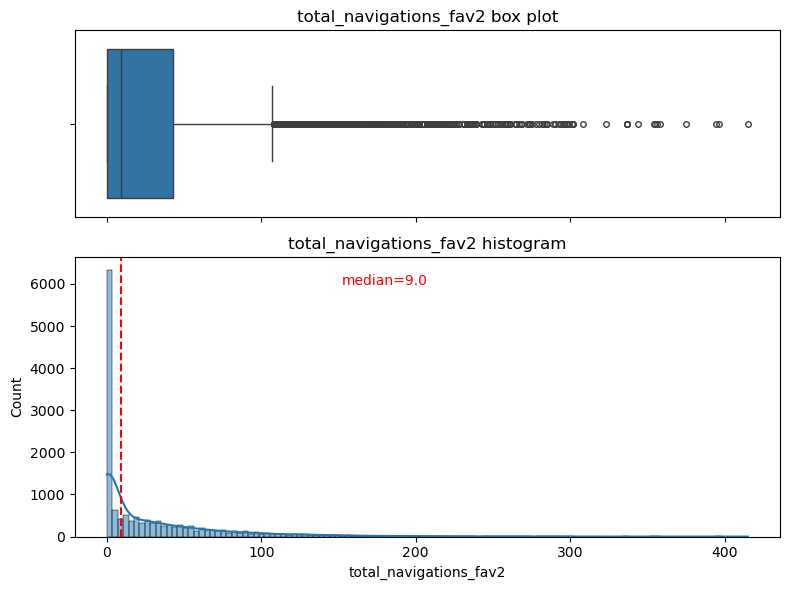

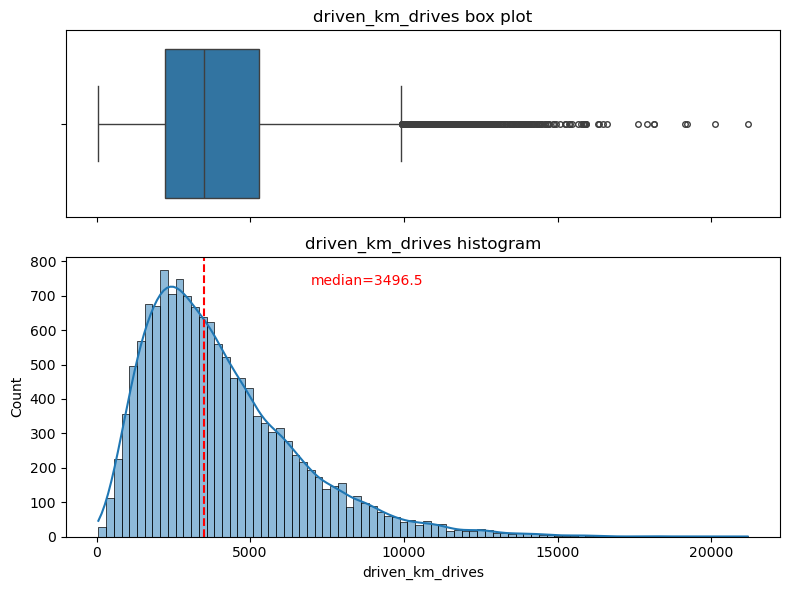

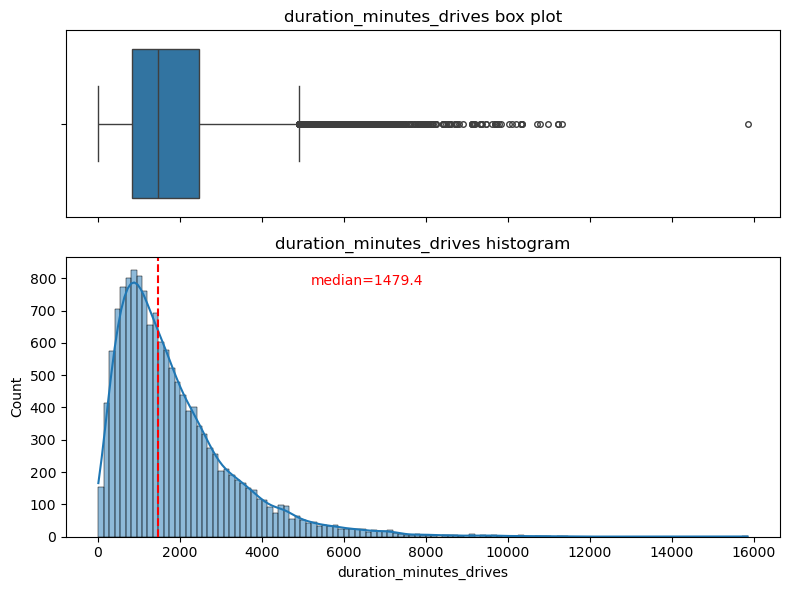

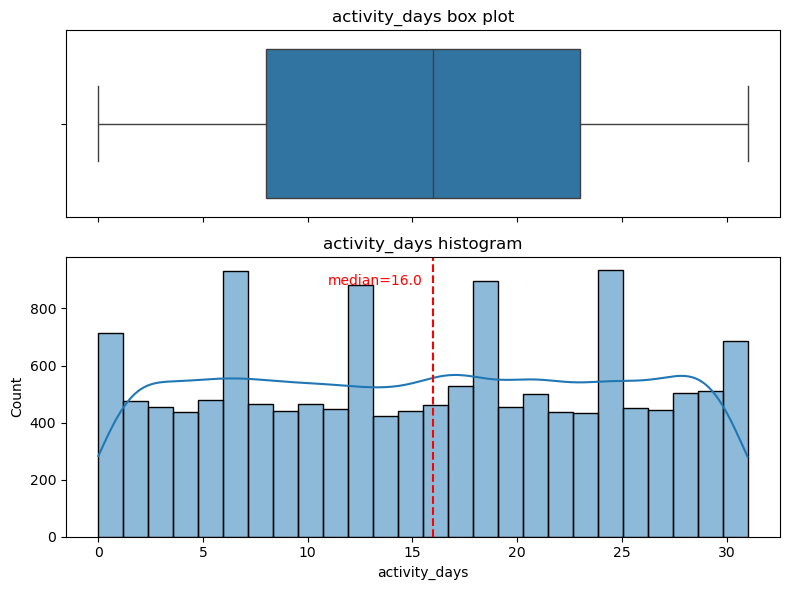

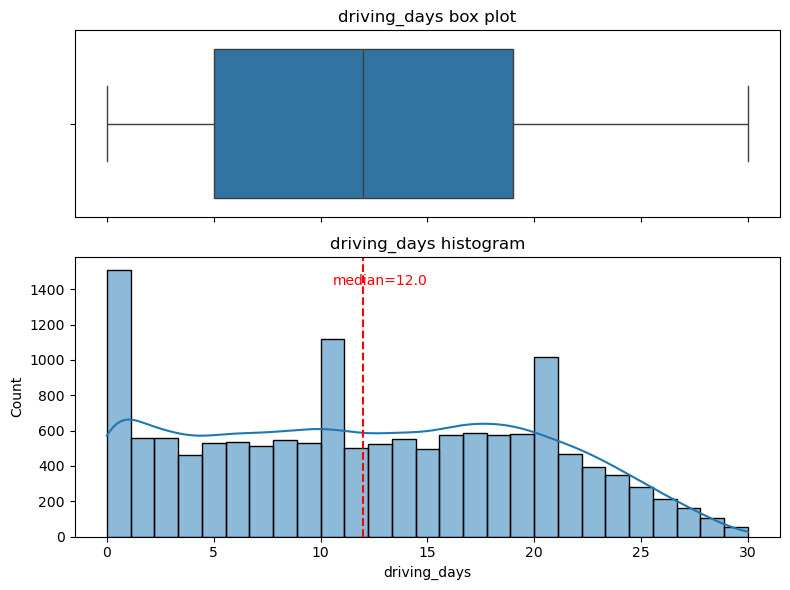

In [15]:
# Select only columns with numeric data types (int, float)
numeric_columns = df.select_dtypes(include=['number']).columns

# Loop through each column and call your function
for col in numeric_columns:
    plot_sessions_distribution(df, col)

##### **Findings:**
> The box plots from the previous section indicated that seven of the variables had clear signs of containing outliers:
* `sessions`
* `drives`
* `total_sessions`
* `total_navigations_fav1`
* `total_navigations_fav2`
* `driven_km_drives`
* `duration_minutes_drives`
> These outliers do not seem to be data entry errors; they are present because of the right-skewed distributions.

##### **Impute outliers**

We do not want to drop outliers since they might contain useful information. For this analysis, we impute the outlying values for these columns. 

We write a function that calculates the 95th percentile of a given column, then imputes values > the 95th percentile with the value at the 95th percentile. such as the 95th percentile of the distribution.

In [16]:
def outlier_imputer(column_name, percentile):
    # Calculate threshold
    threshold = df[column_name].quantile(percentile)
    # Impute threshold for values > than threshold
    df.loc[df[column_name] > threshold, column_name] = threshold

    print('{:>25} | percentile: {} | threshold: {}'.format(column_name, percentile, threshold))

Next, we apply that function to the following columns:
* `sessions`
* `drives`
* `total_sessions`
* `driven_km_drives`
* `duration_minutes_drives`

In [17]:
for column in ['sessions', 'drives', 'total_sessions',
               'driven_km_drives', 'duration_minutes_drives']:
               outlier_imputer(column, 0.95)

                 sessions | percentile: 0.95 | threshold: 243.0
                   drives | percentile: 0.95 | threshold: 200.0
           total_sessions | percentile: 0.95 | threshold: 455.4394923899998
         driven_km_drives | percentile: 0.95 | threshold: 8898.716274999999
  duration_minutes_drives | percentile: 0.95 | threshold: 4668.180091799999


In [18]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,7503.573117,76.539688,63.964683,183.717304,1751.822505,121.747395,29.638296,3944.558631,1792.911210,15.544653,12.182530
std,4331.207621,67.243178,55.127927,118.720520,1008.663834,147.713428,45.350890,2218.358258,1224.329759,9.016088,7.833835
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000
50%,7504.000000,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000
75%,11257.500000,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000
max,14998.000000,243.000000,200.000000,455.439492,3500.000000,1236.000000,415.000000,8898.716275,4668.180092,31.000000,30.000000


### **Part 3: Exploratory Data Analysis**

#### **3.1 Churn portion**
**`label`** column contain a binary target variable (“retained” vs “churned”) that indicates whether a user churned during the month. As a categorical variable, it can be visualized using a pie chart.

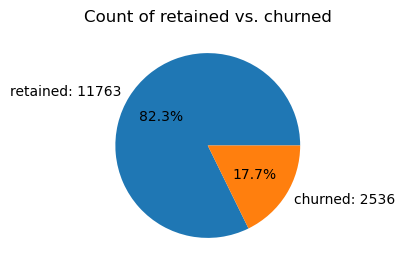

In [19]:
# Pie chart
fig = plt.figure(figsize=(3,3))
data=df['label'].value_counts()
plt.pie(data,
        labels=[f'{data.index[0]}: {data.values[0]}',
                f'{data.index[1]}: {data.values[1]}'],
        autopct='%1.1f%%'
        )
plt.title('Count of retained vs. churned');

##### **Findings:**
> This dataset contains 82% retained users and 18% churned users.

#### **3.2 Churn vs Retention: Median Comparison**
Compare the medians of each variable between churned and retained users. The median is used instead of the mean to avoid the influence of outliers and better represent a typical user.

In [20]:
# Calculate median values of all columns for churned and retained users
df_grouped = df.groupby('label').median(numeric_only=True)

df_grouped

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
label,,,,,,,,,,,
churned,7477.5,59.0,50.0,164.339042,1321.0,84.5,11.0,3652.655666,1607.183785,8.0,6.0
retained,7509.0,56.0,47.0,157.586756,1843.0,68.0,9.0,3464.684614,1458.046141,17.0,14.0


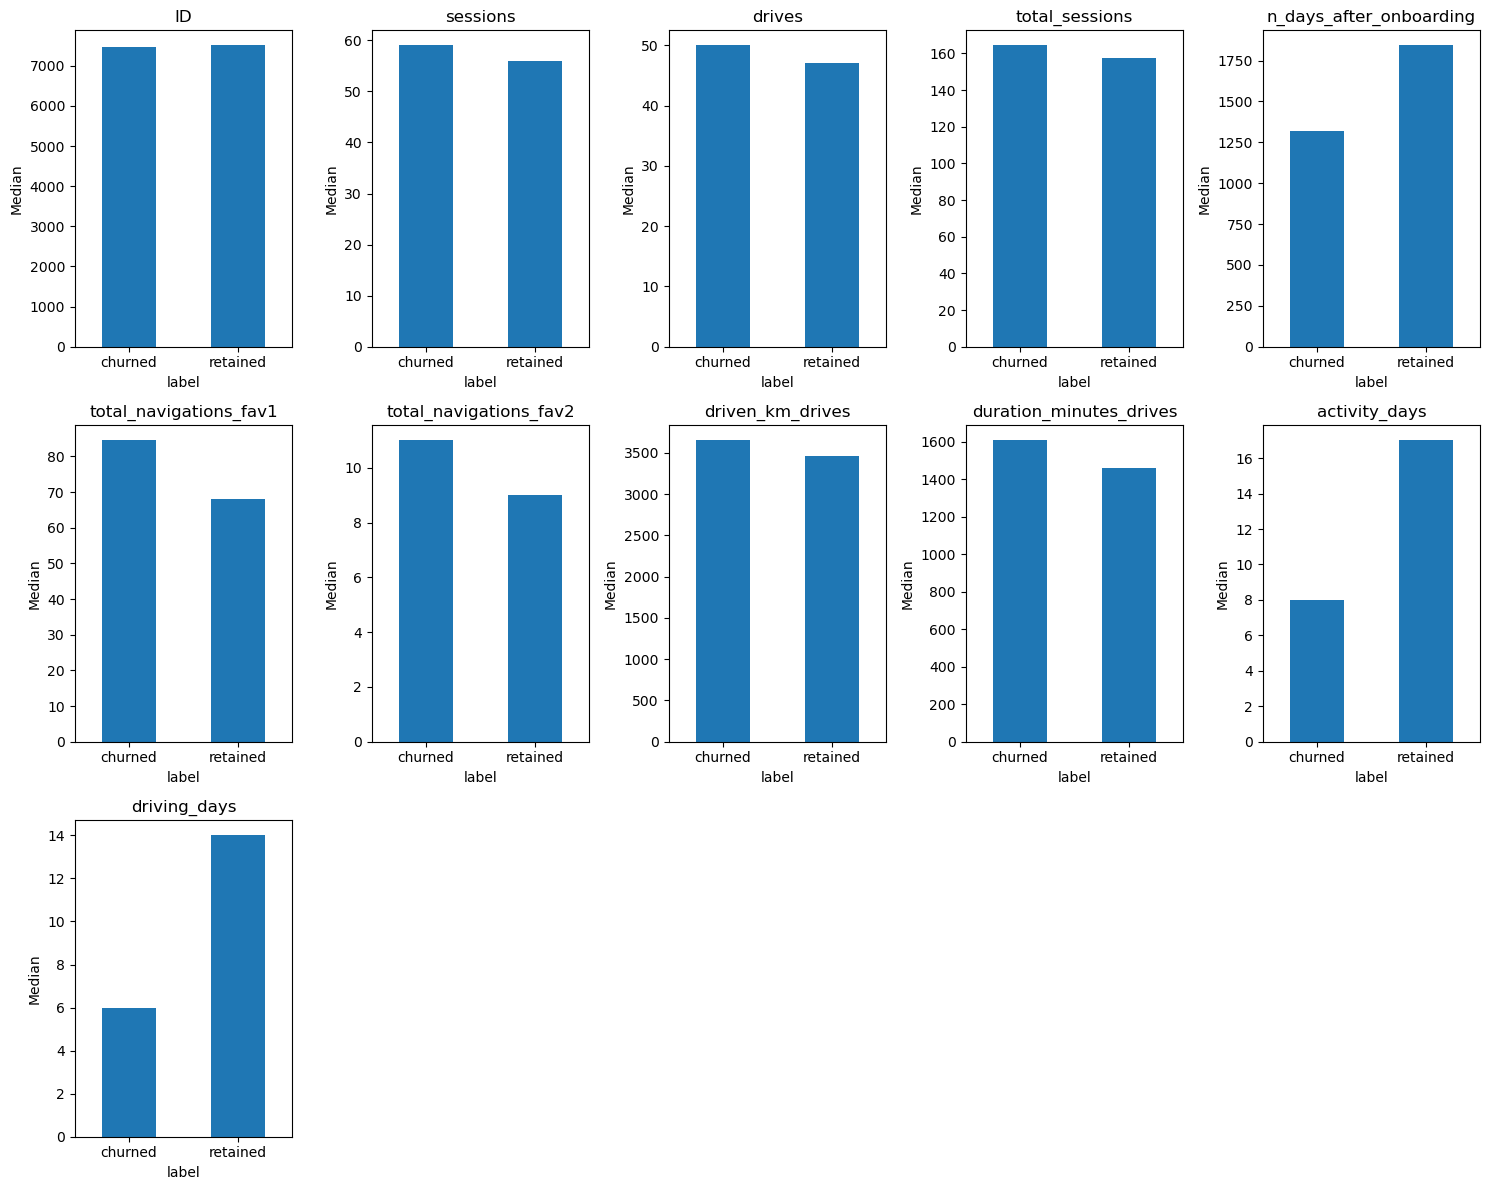

In [21]:
def plot_median_comparison(df_grouped):
    
    features = df_grouped.columns
    n = len(features)
    
    # layout (auto grid)
    cols = 5
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        df_grouped[col].plot(
            kind='bar',
            ax=ax
        )
        
        ax.set_title(col)
        ax.set_ylabel('Median')
        ax.set_xticklabels(['churned', 'retained'], rotation=0)
    
    # remove empty plots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

plot_median_comparison(df_grouped)

##### **Findings:**
> - Churned users are far less active, with 8 vs 17 activity days and 6 vs 14 driving days compared to retained users.
>
> - Churned users drive more per trip (404 km vs 256 km), indicating infrequent but intensive usage.
>
> - Total usage is similar (sessions: 59 vs 56; drives: 50 vs 47), but churned users are much less consistent.
>
> - Retained users have longer onboarding duration (1843 vs 1321 days), suggesting experience reduces churn.
>
> - Navigation activity is slightly higher for churned users (fav1: 84.5 vs 68), but the difference is modest.
>
> - Device and usage ratios show no difference (ratio ≈ 0.82), indicating limited predictive value.


#### **3.3 Churn rate per number of driving days**

Create an histogram to represent the churn rate for each number of driving days.

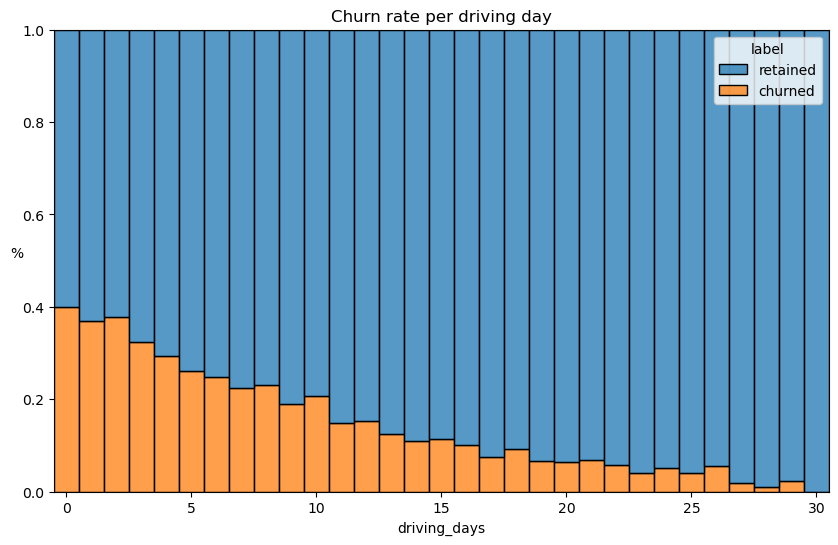

In [22]:
# Histogram
plt.figure(figsize=(10,6))
sns.histplot(data=df,
             x='driving_days',
             bins=range(1,32),
             hue='label',
             multiple='fill',
             discrete=True)
plt.ylabel('%', rotation=0)
plt.title('Churn rate per driving day');

##### **Findings:**
> Churn is highest among users who rarely used Waze in the last month, and it decreases as usage increases. About 40% of users who did not use the app at all churned, while none of the users who used it every day (30 days) churned.

This pattern is expected. High-usage users are likely satisfied, whereas low usage may reflect either prior dissatisfaction or reduced need for the app, such as moving to a location with good public transportation and less driving.

### **Part 4: Feature Engineering**

#### **4.1 Dealing with Categorical Variables**

##### **Dummying features**
Categorical variables cannot be directly processed by most machine learning algorithms. Therefore, dummy encoding was used to transform categorical values into numerical representations suitable for modeling.

In cases where the data contains categorical variables, you can use pandas built-in [`pd.get_dummies()`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html), or you can use scikit-learn's [`OneHotEncoder()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) function.

Because this dataset only has one remaining categorical feature (`device`), it's not necessary to use one of these special functions. You can just implement the transformation directly.

Create a new, binary column called `device2` that encodes user devices as follows:

* `Android` -> `0`
* `iPhone` -> `1`

In [23]:
# Create new `device2` variable
df['device'] = np.where(df['device']=='Android', 0, 1)
df[['device']].tail()

,device
14994,1
14995,0
14996,1
14997,1
14998,1


##### **Target encoding**
The target variable is also categorical, since a user is labeled as either "churned" or "retained." Change the data type of the `label` column to be binary. This change is needed to train the models.

Assign a `0` for all `retained` users.

Assign a `1` for all `churned` users.

Save this variable as `label2` so as not to overwrite the original `label` variable.

**Note:** There are many ways to do this. Consider using `np.where()` as you did earlier in this notebook.



In [24]:
# Create binary `label2` column
df['label'] = np.where(df['label']=='churned', 1, 0)
df[['label',]].tail()

,label
14994,0
14995,0
14996,0
14997,1
14998,0


In [25]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,0,243,200,296.748273,2276,208,0,2628.845068,1985.775061,28,19,0
1,1,0,133,107,326.896596,1225,19,64,8898.716275,3160.472914,13,11,1
2,2,0,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,0
3,3,0,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,1
4,4,0,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,0


#### **4.2 Feature selection**

the only feature that can be cut is `ID`, since it doesn't contain any information relevant to churn.

In [26]:
# Drop `ID` column
df = df.drop(['ID'], axis=1)

#### **4.3 Correlation**

Correlation analysis helps identify redundant variables and multicollinearity issues that may negatively affect machine learning model stability and interpretability. 

Check the correlation among predictor variables. 


In [27]:
# Generate a correlation matrix
df.corr(method='pearson')

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
label,1.000000,0.034911,0.035865,0.024568,-0.129263,0.055537,0.020051,0.019767,0.040407,-0.303851,-0.294259,0.003406
sessions,0.034911,1.000000,0.996942,0.597189,0.007101,0.002982,0.004513,0.002996,-0.004545,0.025113,0.020294,0.012704
drives,0.035865,0.996942,1.000000,0.595285,0.006940,0.002286,0.006165,0.003445,-0.003889,0.024357,0.019608,0.011684
total_sessions,0.024568,0.597189,0.595285,1.000000,0.006596,0.000863,0.007780,0.001016,-0.000338,0.015755,0.012953,0.012138
n_days_after_onboarding,-0.129263,0.007101,0.006940,0.006596,1.000000,-0.004536,-0.006433,-0.004652,-0.010167,-0.009418,-0.007321,-0.011299
total_navigations_fav1,0.055537,0.002982,0.002286,0.000863,-0.004536,1.000000,0.003734,-0.006481,0.007306,0.010318,0.010024,-0.000679
total_navigations_fav2,0.020051,0.004513,0.006165,0.007780,-0.006433,0.003734,1.000000,0.004003,-0.004345,-0.004836,0.000938,0.001079
driven_km_drives,0.019767,0.002996,0.003445,0.001016,-0.004652,-0.006481,0.004003,1.000000,0.690515,-0.007441,-0.009549,-0.002091
duration_minutes_drives,0.040407,-0.004545,-0.003889,-0.000338,-0.010167,0.007306,-0.004345,0.690515,1.000000,-0.007895,-0.009425,-0.007709
activity_days,-0.303851,0.025113,0.024357,0.015755,-0.009418,0.010318,-0.004836,-0.007441,-0.007895,1.000000,0.947687,-0.010221


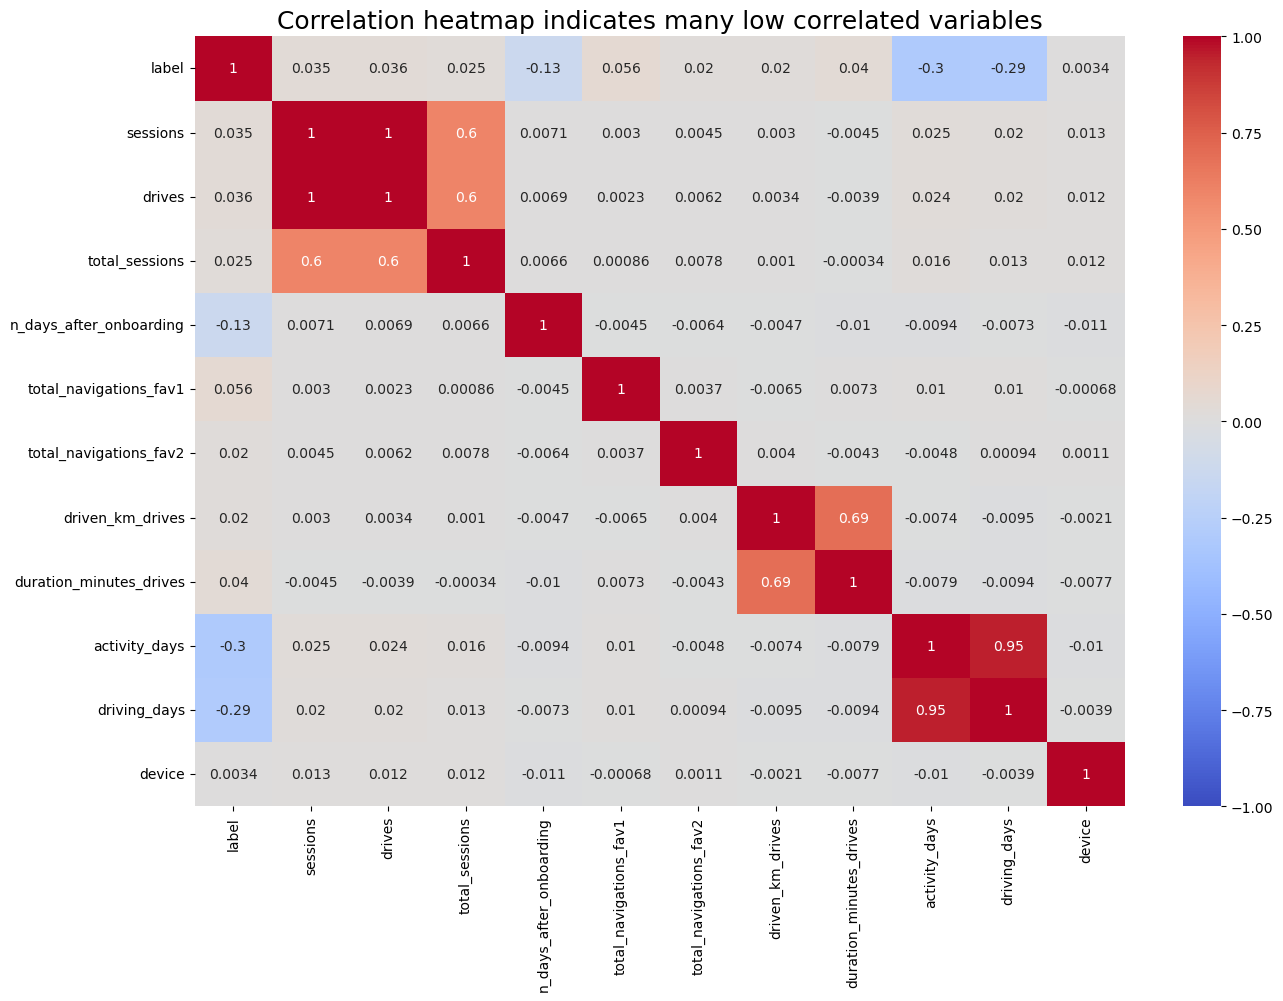

In [28]:
# plot a correlation heatmap
# Plot correlation heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(method='pearson'), vmin=-1, vmax=1, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap indicates many low correlated variables',
          fontsize=18)
plt.show();

##### **Findings:**
> The data shows strong multicollinearity between several variables, particularly between `sessions` and `drives` (correlation = 1.0), as well as between `driving_days` and `activity_days` (correlation = 0.95).

### **Part 5: Hypothesis testing**

The following hypotheses were developed based on patterns observed during exploratory data analysis.

**Hypothesis 1**

Users who churn have significantly fewer activity days than retained users.

**Hypothesis 2**

The average number of drives differs among users with different levels of driving activity.

**Hypothesis 3**

User churn is associated with device type (Android vs. iPhone).

These hypotheses are evaluated using statistical significance testing in the following sections.

#### **5.1 t test**

An independent two-sample t-test is used to compare the average number of drives between Android and iPhone users, as the two groups are independent.

**Hypotheses:**

Null hypothesis $H_0$: There is no difference in average number of drives between drivers who use iPhone devices and drivers who use Androids.

Alternative hypothesis $H_A$: There is a difference in average number of drives between drivers who use iPhone devices and drivers who use Androids.

In [29]:
# 1. Isolate the `drives` column for iPhone users.
iPhone = df[df['device'] == 1]['drives']

# 2. Isolate the `drives` column for Android users.
Android = df[df['device'] == 0]['drives']

# 3. Perform the t-test
stats.ttest_ind(a=iPhone, b=Android, equal_var=False)

TtestResult(statistic=1.4057121891392934, pvalue=0.1598388152623599, df=10636.379585225877)

**Findings:**
> Since the p-value is larger than the chosen significance level (5%), you fail to reject the null hypothesis. The t-test results concluded there is **not** a statistically signiﬁcant difference in mean number of rides between iPhone users and Android users.

#### **5.2 ANOVA**

In [30]:
df.head()

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,243,200,296.748273,2276,208,0,2628.845068,1985.775061,28,19,0
1,0,133,107,326.896596,1225,19,64,8898.716275,3160.472914,13,11,1
2,0,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,0
3,0,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,1
4,0,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,0


We will compare the number of drives with 0-10 driving days, 11-20 driving days, and 21-30 driving days.

In this analysis, we use a one-way ANOVA to determine whether the **average number of drives** (defined as the number of times a user drove at least 1 km during the month) differs across three groups of users based on their **number of driving days**. The significance level is set at α = 0.05.


##### **Step 1: Create driving day groups**

Users are categorized into three groups based on their driving frequency:

- 0–10 days (low activity)  
- 11–20 days (moderate activity)  
- 21–30 days (high activity)  


In [31]:
df['driving_days_group'] = pd.cut(
    df['driving_days'],
    bins=[0, 10, 20, 30],
    labels=['0-10', '11-20', '21-30'],
    include_lowest=True
)

##### **Step 2: Visualize the Distribution**

A boxplot is used to compare the distribution of `drives` across the three groups.

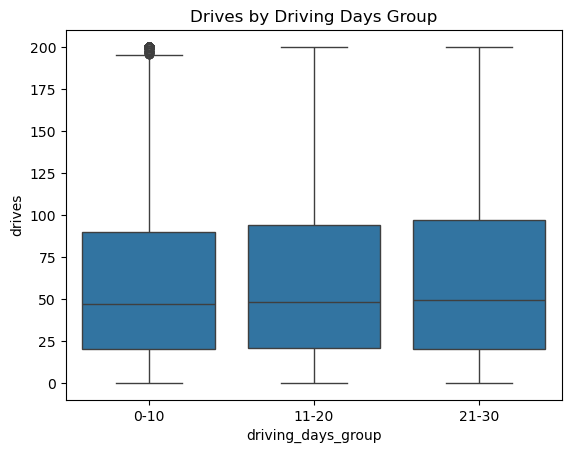

In [32]:
sns.boxplot(
    data=df,
    x='driving_days_group',
    y='drives'
)

plt.title('Drives by Driving Days Group')
plt.show()

The median number of drives appears similar across groups, with slightly higher values in the higher activity groups, but the distributions largely overlap.

##### **Step 3: Perform One-Way ANOVA**

We test whether the mean number of drives differs across the three groups.

**Null hypothesis $ 𝐻_{0}$**: $\mu_{1}=\mu_{2}=\mu_{3}: $ The mean number of drives in 0-10 driving days, 11-20 driving days, and 21-30 driving days are the same. \
**Alternative hypothesis $𝐻_{A}$**:  At least one group has a different mean number of drives


In [33]:
from scipy.stats import f_oneway

group1 = df[df['driving_days_group']=='0-10']['drives']
group2 = df[df['driving_days_group']=='11-20']['drives']
group3 = df[df['driving_days_group']=='21-30']['drives']

f_stat, p_value = f_oneway(group1, group2, group3)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 1.6179255248457383
p-value: 0.19834597066612705


##### **Findings:**
> Since the p-value (0.198) is greater than 0.05, we fail to reject the null hypothesis. \
> There is no statistically significant difference in the average number of drives across the three driving-day groups.

Although users with more driving days appear to have slightly higher total drives, the differences are small and not statistically significant. Therefore, we cannot conclude that the number of driving days meaningfully affects the total number of drives.

This suggests that *driving more days does not necessarily translate into a significantly higher number of total driving events*, likely because users with fewer driving days may drive more frequently within those days.

#### **5.3 Chi-square test**

In this analysis, we use a chi-square test of independence to determine whether **device type (iPhone vs. Android)** is associated with **user churn status**. The significance level is set at α = 0.05.


##### **Step 1: Visualize the Distribution**

A count plot is used to compare the number of retained and churned users across device types.

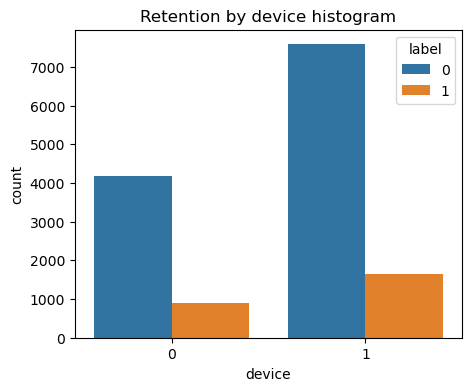

In [34]:
# Histogram
plt.figure(figsize=(5,4))
sns.countplot(data=df,
             x='device',
             hue='label',
             )
plt.title('Retention by device histogram');

Both device groups show similar proportions of retained and churned users, suggesting no obvious relationship between device type and churn.

##### **Step 2: Create Contingency Table**

We summarize the counts of users by device type and churn status.

In [35]:
# Create contingency table
table = pd.crosstab(df['device'], df['label'])


##### **Step 3: Perform Chi-Square Test**

We test whether device type and churn status are independent.

**Hypotheses**

**$𝐻_{0}$ (null hypothesis)**: Device type and churn status are independent \
**$𝐻_{A}$ (alternative hypothesis)**: Device type and churn status are associated

In [36]:
chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 0.7007211845963163


##### **Findings:**
> Since the p-value (0.70) is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant association between device type and user churn.

Device type does not appear to influence whether a user churns. Therefore, it is unlikely to be a useful predictor for churn in this dataset.

### **Part 6: Conclusion**
This project explored user behavior patterns in the Waze dataset using exploratory data analysis, data cleaning, feature engineering, and statistical testing.

The analysis showed that user inactivity is strongly associated with churn. Churned users generally had fewer activity days and driving days, while retained users demonstrated more consistent engagement with the platform. Longer onboarding duration was also associated with higher retention.

The statistical tests further confirmed that Variables related to user activity were more useful for understanding churn than whether the user used Android or iPhone.

Several variables also exhibited strong multicollinearity, which should be considered during future machine learning model development.

## **Author**

Su Wu
